In [14]:
import sys
!{sys.executable} -m pip install --user geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 44.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 38.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


In [1]:
import pandas as pd
import fpsnippets as fp
import matplotlib.pyplot as plt
stores = pd.read_csv('stores.csv')
inspections = pd.read_csv('inspections.csv')

In [2]:
print(stores.columns.tolist())
clean_s = stores.dropna(subset=["latitude", "longitude"]).copy()

print(f"stores:{len(clean_s)}")
#inspections.head()

['_id', 'store_id', 'store_name', 'address', 'mailing_city', 'state', 'zip', 'municipality', 'corp_id', 'neighborhood', 'longitude', 'latitude', 'business_phone', 'alternate_phone', 'price_verification', 'fuel_dispenser', 'scale', 'timing', 'misc_inspection', 'oob', 'unit', 'shopping_center', 'new_municipality']
stores:3665


In [3]:
#fpsnippets for neighborhoods
clean_s["neighborhood"] = clean_s.apply( lambda row: fp.geo_to_neighborhood(row["latitude"], row["longitude"]), axis=1)


In [7]:
combo = inspections.merge(clean_s[["store_id", "store_name", "neighborhood"]], on="store_id")

insp_per_nei = combo.groupby("neighborhood").size().rename("total_insp")
violation_per =(combo[combo["result"] == "Fail"].groupby("neighborhood").size().rename("violations"))
vio_per_hood = pd.concat([insp_per_nei, violation_per],axis=1).fillna(0)
vio_per_hood["rate"] = vio_per_hood["violations"]/ vio_per_hood["total_insp"]

vio_per_hood = vio_per_hood.sort_values("rate")
print(vio_per_hood.head(10))

                       total_insp  violations  rate
neighborhood                                       
Beltzhoover                     6         0.0   0.0
Bluff                          60         0.0   0.0
Brighton Heights              207         0.0   0.0
Friendship                     70         0.0   0.0
Glen Hazel                      2         0.0   0.0
Homewood North                  2         0.0   0.0
Summer Hill                   147         0.0   0.0
Spring Hill-City View           2         0.0   0.0
Oakwood                         5         0.0   0.0
Polish Hill                     2         0.0   0.0


In [26]:
#Ran into issue involving executing the above cell multiple times skewing the data (?)

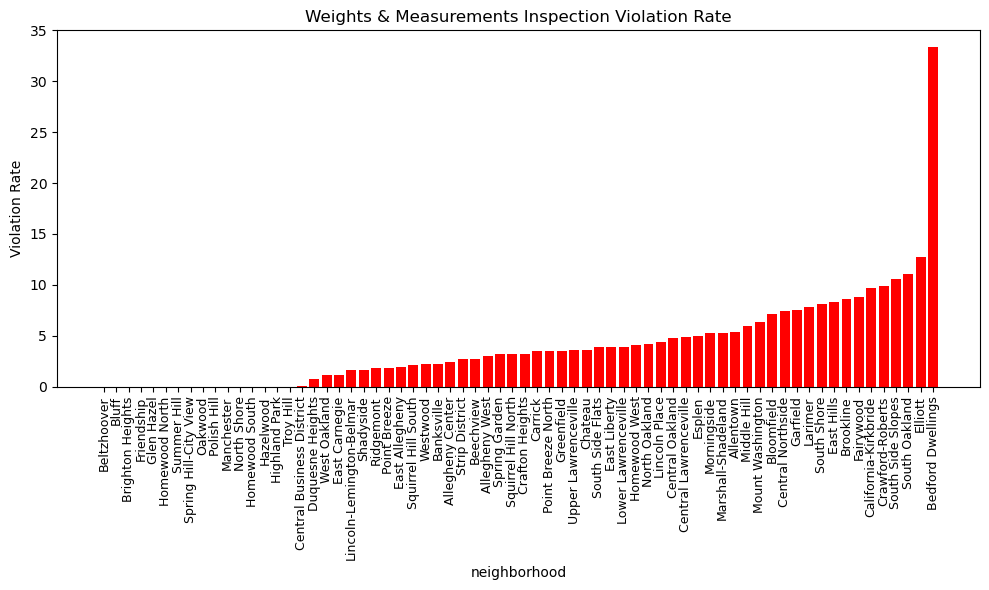

In [22]:
#Find Best Neighborhood based on violations per insp #
best_hood = vio_per_hood.index[0]
fig, ax = plt.subplots(figsize=(10,6))
vio_plot = vio_per_hood.sort_values("rate")
bars = ax.bar( vio_plot.index, vio_plot["rate"] * 100, color=["red" for n in vio_plot.index])

ax.set_xlabel("neighborhood")
ax.set_ylabel("Violation Rate")
ax.set_title("Weights & Measurements Inspection Violation Rate")
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

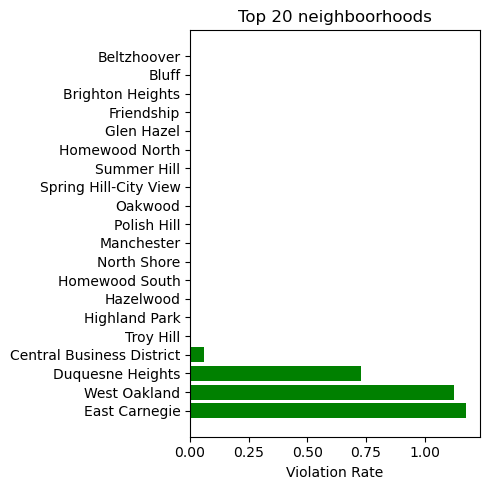

In [23]:
top20 = vio_per_hood.sort_values("rate").head(20)

fig, ax = plt.subplots(figsize=(5,5))
ax.barh(top20.index[::-1], top20["rate"][::-1] * 100, color= "green")
ax.set_xlabel("Violation Rate")
ax.set_title("Top 20 neighboorhoods")
plt.tight_layout()
plt.show()

In [24]:
# Create a minimum to now skew results to much
MIN_INSP = 10

improved_vio = vio_per_hood[vio_per_hood["total_insp"] >= MIN_INSP]
new_best = improved_vio.sort_values("rate").index[0]
print(improved_vio.head(10))

                           total_insp  violations      rate
neighborhood                                               
Bluff                              60         0.0  0.000000
Brighton Heights                  207         0.0  0.000000
Friendship                         70         0.0  0.000000
Summer Hill                       147         0.0  0.000000
Manchester                         82         0.0  0.000000
North Shore                        61         0.0  0.000000
Hazelwood                          12         0.0  0.000000
Highland Park                      22         0.0  0.000000
Troy Hill                         105         0.0  0.000000
Central Business District       13515         8.0  0.000592


# Conclusion
By sheer number to violation difference generally, Central Business District(Downtown) technically could count although, in terms of number of inspections in relation to violation rate, Brighton Heights would be the best neighborhood as it has 0 violations in over 200+ inspections.